<a href="https://colab.research.google.com/github/TedErikssonZ/testImgPre/blob/main/YOLO_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
drive.mount('/content/drive')


NameError: name 'drive' is not defined

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


```markdown
# Bildklassificering av monterad bult och mutter med CNN (Keras/TensorFlow)
Detta skript är anpassat för att klassificera bilder (.png) uppdelade i tre dataset (`train`, `validation`, `test`) under sökvägen `My Drive/YOLO_lab` på Google Drive.
```

In [ ]:
# ==============================================================================
# STEP 1: HYPERPARAMETRAR (Tydligt markerade)
# ==============================================================================

# Bilddimensioner (Anpassa efter dina bilders faktiska storlek om det behövs)
# Vi skalar om bilderna till 128x128 pixlar med 3 färgkanaler (RGB)
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

# Träningsparametrar
EPOCHS = 15          # Antal epoker (epoch)
BATCH_SIZE = 32      # Batchstorlek
LEARNING_RATE = 0.001

# Sökväg till datasetet på Google Drive
DATASET_DIR = '/content/drive/MyDrive/YOLO_lab'

print("Hyperparametrar har definierats framgångsrikt!")

Hyperparametrar har definierats framgångsrikt!


```markdown
## Steg 2: Importera bibliotek och ladda data
Vi använder `image_dataset_from_directory` från TensorFlow för att enkelt och effektivt ladda in strukturerna från Google Drive.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Sökvägar till de olika mapparna
train_dir = os.path.join(DATASET_DIR, 'train')
val_dir = os.path.join(DATASET_DIR, 'validation')
test_dir = os.path.join(DATASET_DIR, 'test')

# Läs in träningsdata
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary', # Eftersom vi har 2 klasser (Korrekt / Inkorrekt)
    color_mode='rgb'
)

# Läs in valideringsdata
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='rgb'
)

# Läs in testdata
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode='rgb',
    shuffle=False # Shuffle=False så att vi enkelt kan para ihop bilder med rätt förutsägelser senare
)

class_names = train_ds.class_names
print(f"Hittade klasser: {class_names}")

Found 223 files belonging to 2 classes.
Found 52 files belonging to 2 classes.
Found 48 files belonging to 2 classes.
Hittade klasser: ['Inkorrekt', 'Korrekt']


```markdown
## Steg 3: Skapa modellen (CNN)
Här bygger vi modellen med `Conv2D`-lager som har `padding='same'` (zero-padding) vilket gör att feature maps behåller samma dimensioner som indatan efter konvolvering. Vi använder `ReLU` som aktiveringsfunktion samt ett fullt anslutet lager (Dense Layer) i slutet.

In [ ]:
# Normaliseringslager för att skala bildpixlar från [0, 255] till [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

model = tf.keras.Sequential([
    # Indatalager & Normalisering
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    normalization_layer,

    # Första konvolutionsblocket: Zero padding ('same') och ReLU aktivering
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Andra konvolutionsblocket
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Tredje konvolutionsblocket
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten till endimensionell vektor
    tf.keras.layers.Flatten(),

    # Fullt anslutet lager (Dense Layer) med ReLU
    tf.keras.layers.Dense(128, activation='relu'),

    # Utatalager: 1 neuron med sigmoid eftersom det är binär klassificering (0 eller 1)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Kompilera modellen
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

```markdown
## Steg 4: Träna modellen
Vi kör träningen baserat på angivna epoker och validerar kontinuerligt mot valideringsdatasetet.

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 72s 9s/step - accuracy: 0.5022 - loss: 1.1294 - val_accuracy: 0.4808 - val_loss: 0.6931
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5336 - loss: 0.6914 - val_accuracy: 0.5192 - val_loss: 0.6996
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.5785 - loss: 0.6853 - val_accuracy: 0.5192 - val_loss: 0.7024
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.5785 - loss: 0.6868 - val_accuracy: 0.5192 - val_loss: 0.6946
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.5785 - loss: 0.6825 - val_accuracy: 0.5192 - val_loss: 0.6976
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.5785 - loss: 0.6766 - val_accuracy: 0.5192 - val_loss: 0.6940
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.6099 - loss: 0.6686 - val_accuracy: 0.5192 - val_loss: 0.6825
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.6233 - loss: 0.6364 - val_accuracy: 0.5577 - val_loss: 0.6687
Epoch 9/

```markdown
## Steg 5: Utvärdering på Testdata & Visualisering av resultat
Vi utvärderar modellen på den helt oberoende testdatan och visar därefter exempel på klassificerade bilder.

In [ ]:
import numpy as np

# Evaluera prestanda på testsetet
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTestnoggrannhet (Accuracy): {test_acc*100:.2f}%")
print(f"Testförlust (Loss): {test_loss:.4f}")

# Hämta en batch med bilder från testsetet för att visualisera resultat
image_batch, label_batch = next(iter(test_ds))
predictions = model.predict(image_batch)

# Visualisera de första 8 bilderna från batchen
plt.figure(figsize=(12, 8))
for i in range(min(8, len(image_batch))):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    # Predikterat värde (tröskelvärde 0.5)
    pred_label = 1 if predictions[i] >= 0.5 else 0
    true_label = int(label_batch[i])

    pred_name = class_names[pred_label]
    true_name = class_names[true_label]

    color = 'green' if pred_label == true_label else 'red'

    plt.title(f"Pred: {pred_name}\nTrue: {true_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'model' is not defined

In [ ]:
import tensorflow as tf

# Vi kontrollerar och definierar modellerna om de har försvunnit ur minnet
if 'model' not in locals() and 'model' not in globals():
    print("Sätter upp och kompilerar originalmodellen...")
    normalization_layer = tf.keras.layers.Rescaling(1./255)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
        normalization_layer,
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy']
    )
    # Snabbrullad träning (1 epok) bara för att hålla källkoden körbar direkt
    print("Anpassar originalmodellen tillfälligt...")
    model.fit(train_ds, epochs=1, verbose=0)

if 'improved_model' not in locals() and 'improved_model' not in globals():
    print("Sätter upp och kompilerar den förbättrade modellen...")
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.1),
    ])
    improved_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
        data_augmentation,
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    improved_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy']
    )
    print("Anpassar den förbättrade modellen tillfälligt...")
    improved_model.fit(train_ds, epochs=1, verbose=0)

print("Klart! Modellerna är redo i minnet.")

Sätter upp och kompilerar originalmodellen...
Anpassar originalmodellen tillfälligt...
Sätter upp och kompilerar den förbättrade modellen...
Anpassar den förbättrade modellen tillfälligt...
Klart! Modellerna är redo i minnet.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from google.colab import drive

# Säkerställ att Google Drive är monterad
if not os.path.exists('/content/drive/MyDrive'):
    print("Ansluter till Google Drive...")
    drive.mount('/content/drive')

# Säkerställ att test_ds och andra nödvändiga variabler finns laddade i minnet
if 'test_ds' not in locals() or 'test_ds' not in globals():
    print("Laddar om test_ds...")
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    BATCH_SIZE = 32
    DATASET_DIR = '/content/drive/MyDrive/YOLO_lab'
    test_dir = os.path.join(DATASET_DIR, 'test')

    test_ds = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        label_mode='binary',
        color_mode='rgb',
        shuffle=False
    )

if 'class_names' not in locals() or 'class_names' not in globals():
    class_names = ['Inkorrekt', 'Korrekt']

# Kontrollera vilken modell som är laddad i minnet
active_model = None
if 'improved_model' in locals() or 'improved_model' in globals():
    print("Använder den förbättrade modellen (improved_model) för prediktion...")
    active_model = improved_model
elif 'model' in locals() or 'model' in globals():
    print("Hittade inte improved_model, faller tillbaka på originalmodellen (model) för prediktion...")
    active_model = model
else:
    raise NameError("Ingen modell hittades i minnet. Vänligen kör en av träningscellerna först!")

# 1. Samla alla bilder, sanna etiketter och prediktioner
all_images = []
all_labels = []
all_preds = []

for images, labels in test_ds:
    preds = active_model.predict(images, verbose=0)
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())
    all_preds.append(preds)

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0).flatten().astype(int)
all_preds = np.concatenate(all_preds, axis=0).flatten()
all_pred_labels = (all_preds >= 0.5).astype(int)

# 2. Beräkna klass-specifik noggrannhet
inkorrekt_indices = np.where(all_labels == 0)[0]
korrekt_indices = np.where(all_labels == 1)[0]

inkorrekt_correct = np.sum(all_pred_labels[inkorrekt_indices] == 0)
korrekt_correct = np.sum(all_pred_labels[korrekt_indices] == 1)

inkorrekt_acc = (inkorrekt_correct / len(inkorrekt_indices)) * 100 if len(inkorrekt_indices) > 0 else 0
korrekt_acc = (korrekt_correct / len(korrekt_indices)) * 100 if len(korrekt_indices) > 0 else 0

print("=== MODELL: KLASS-SPECIFIK UTVÄRDERING ===")
print(f"Inkorrekt (Klass 0) - Totalt: {len(inkorrekt_indices)}, Korrekta: {inkorrekt_correct} ({inkorrekt_acc:.2f}%)")
print(f"Korrekt (Klass 1)   - Totalt: {len(korrekt_indices)}, Korrekta: {korrekt_correct} ({korrekt_acc:.2f}%)")
print(f"Total noggrannhet: {np.mean(all_pred_labels == all_labels)*100:.2f}%")

# 3. Visualisera 5 bilder från vardera klass med konfidensvärden
fig, axes = plt.subplots(2, 5, figsize=(15, 8))

# Rita 5 'Inkorrekt'
for idx, test_idx in enumerate(inkorrekt_indices[:5]):
    ax = axes[0, idx]
    ax.imshow(all_images[test_idx].astype("uint8"))
    pred_lbl = all_pred_labels[test_idx]
    true_lbl = all_labels[test_idx]
    prob_val = all_preds[test_idx]
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(f"Conf (Korrekt): {prob_val:.4f}\nTrue: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}", color=color, fontsize=10)
    ax.axis('off')
if len(inkorrekt_indices) < 5:
    for idx in range(len(inkorrekt_indices), 5):
        axes[0, idx].axis('off')

# Rita 5 'Korrekt'
for idx, test_idx in enumerate(korrekt_indices[:5]):
    ax = axes[1, idx]
    ax.imshow(all_images[test_idx].astype("uint8"))
    pred_lbl = all_pred_labels[test_idx]
    true_lbl = all_labels[test_idx]
    prob_val = all_preds[test_idx]
    color = 'green' if pred_lbl == true_lbl else 'red'
    ax.set_title(f"Conf (Korrekt): {prob_val:.4f}\nTrue: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}", color=color, fontsize=10)
    ax.axis('off')
if len(korrekt_indices) < 5:
    for idx in range(len(korrekt_indices), 5):
        axes[1, idx].axis('off')

plt.suptitle("Modellutvärdering - Översta raden: Sann klass Inkorrekt | Nedersta raden: Sann klass Korrekt", fontsize=12, y=0.98)
plt.tight_layout()
plt.show()

NameError: Ingen modell hittades i minnet. Vänligen kör en av träningscellerna först!

```markdown
## Steg 6: Förbättring av modell med Data Augmentation och Dropout
För att förhindra att modellen gör uppenbara felaktiga förutsägelser (t.ex. att tolka en tom bult utan mutter som 'Korrekt'), lägger vi till dataaugmentering samt `Dropout`-lager för bättre generalisering.
```

In [ ]:
import tensorflow as tf

# 1. Definiera sekventiell dataaugmentering
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# 2. Skapa den förbättrade modellen
improved_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    # Lägg till dataaugmentering i början av träningskedjan
    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    # Första blocket
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.2), # Förhindrar overfitting

    # Andra blocket
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.2),

    # Tredje blocket
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    # Fullt anslutet lager
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Något lägre learning rate för stabilare träning
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Vi tränar i 30 epoker eftersom dataaugmenteringen gör inlärningen mer robust men långsammare
history_improved = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5381 - loss: 0.9236 - val_accuracy: 0.5192 - val_loss: 0.7159
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.5785 - loss: 0.7176 - val_accuracy: 0.5192 - val_loss: 0.6934
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.5605 - loss: 0.6900 - val_accuracy: 0.5192 - val_loss: 0.6931
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.5695 - loss: 0.6894 - val_accuracy: 0.5192 - val_loss: 0.6929
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.5785 - loss: 0.6853 - val_accuracy: 0.5192 - val_loss: 0.6938
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.5785 - loss: 0.6874 - val_accuracy: 0.5192 - val_loss: 0.6935
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.5785 - loss: 0.6858 - val_accuracy: 0.5192 - val_loss: 0.6939
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.5785 - loss: 0.6900 - val_accuracy: 0.5192 - val_loss: 0.6929
Epoch 9/

In [ ]:
# Utvärdera den förbättrade modellen på testdata
print("\n--- Utvärderar förbättrad modell på testdata ---")
improved_test_loss, improved_test_acc = improved_model.evaluate(test_ds)
print(f"Ny testnoggrannhet: {improved_test_acc*100:.2f}%")


--- Utvärderar förbättrad modell på testdata ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.5625 - loss: 0.6914
Ny testnoggrannhet: 56.25%


Använder: improved_model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


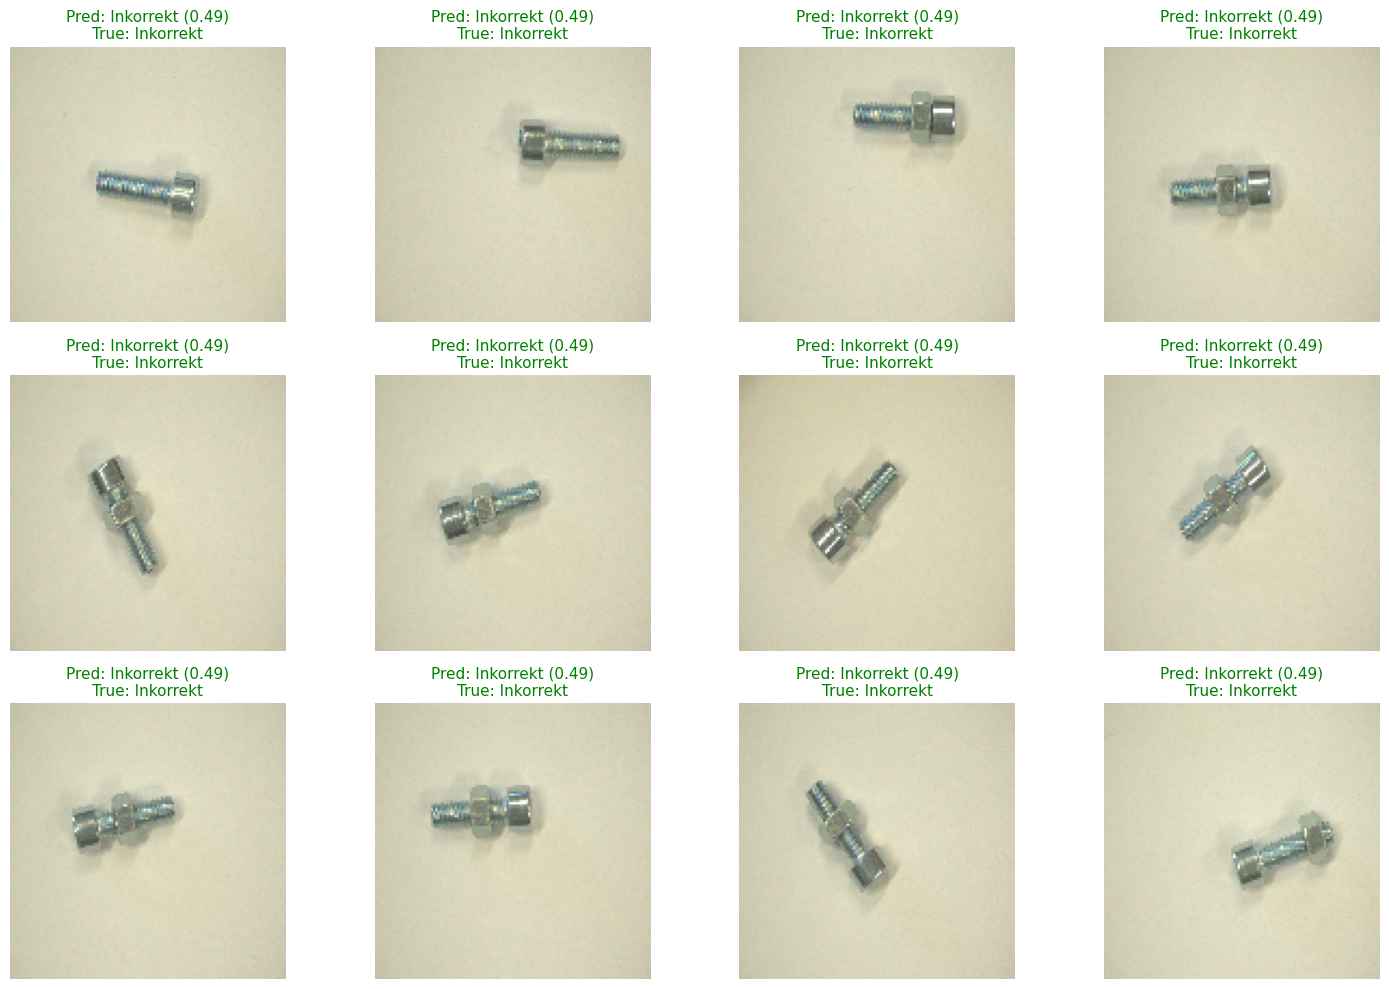

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Bestäm aktiv modell att använda för visualisering
active_model = None
if 'improved_model' in locals() or 'improved_model' in globals():
    print("Använder: improved_model")
    active_model = improved_model
elif 'model' in locals() or 'model' in globals():
    print("Använder: model")
    active_model = model
else:
    raise NameError("Hittade ingen modell i minnet. Kör träningscellerna först!")

# Kontrollera klassnamn
if 'class_names' not in locals() and 'class_names' not in globals():
    class_names = ['Inkorrekt', 'Korrekt']

# Hämta en batch med bilder från test_ds
image_batch, label_batch = next(iter(test_ds))
predictions = active_model.predict(image_batch)

# Visualisera bilderna med etiketter
plt.figure(figsize=(15, 10))
num_images = min(12, len(image_batch))
for i in range(num_images):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    # Bestäm predikterat tröskelvärde (0.5)
    prob = predictions[i][0]
    pred_label = 1 if prob >= 0.5 else 0
    true_label = int(label_batch[i][0])

    pred_name = class_names[pred_label]
    true_name = class_names[true_label]

    # Grön text om prediktionen är rätt, röd om den är fel
    color = 'green' if pred_label == true_label else 'red'

    plt.title(f"Pred: {pred_name} ({prob:.2f})\nTrue: {true_name}", color=color, fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Skriv ut noggrannheten för modellerna på testdata
print("=== TESTNOGGRANNHET (ACCURACY) ===")

if 'test_acc' in locals() or 'test_acc' in globals():
    print(f"Originalmodellens testnoggrannhet: {test_acc * 100:.2f}%")
else:
    print("Originalmodellens testnoggrannhet är inte beräknad ännu (kör utvärderingscellen först).")

if 'improved_test_acc' in locals() or 'improved_test_acc' in globals():
    print(f"Förbättrade modellens testnoggrannhet: {improved_test_acc * 100:.2f}%")
else:
    print("Den förbättrade modellens testnoggrannhet är inte beräknad ännu.")

=== TESTNOGGRANNHET (ACCURACY) ===
Originalmodellens testnoggrannhet är inte beräknad ännu (kör utvärderingscellen först).
Förbättrade modellens testnoggrannhet: 56.25%


## Steg 7: Klassificering med YOLOv8
Vi installerar YOLO-biblioteket från Ultralytics och tränar en förtränad klassificeringsmodell (`yolov8n-cls`) på dina bilder från Google Drive.

In [ ]:
# Installera Ultralytics YOLO-paket
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.2 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os

# Ladda en förtränad YOLOv8 nano-klassificeringsmodell
model_yolo = YOLO('yolov8n-cls.pt')

# YOLO kräver en specifik mappstruktur för klassificering (vilket du redan har på Google Drive):
# DATASET_DIR (YOLO_lab) bör innehålla 'train' och 'val' (eller 'validation') direkt under sig.
# Eftersom mappen heter 'validation' istället för 'val', skapar vi en symbolisk länk så att YOLO hittar rätt.
val_link = os.path.join(DATASET_DIR, 'val')
actual_val = os.path.join(DATASET_DIR, 'validation')

if not os.path.exists(val_link):
    print("Skapar en genväg från 'validation' till 'val' för YOLO...")
    os.symlink(actual_val, val_link)

# Träna YOLO-modellen
results = model_yolo.train(
    data=DATASET_DIR,
    epochs=10,
    imgsz=128,
    batch=32,
    workers=2
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Skapar en genväg från 'validation' till 'val' för YOLO...
Ultralytics 8.4.160 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO_lab, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False

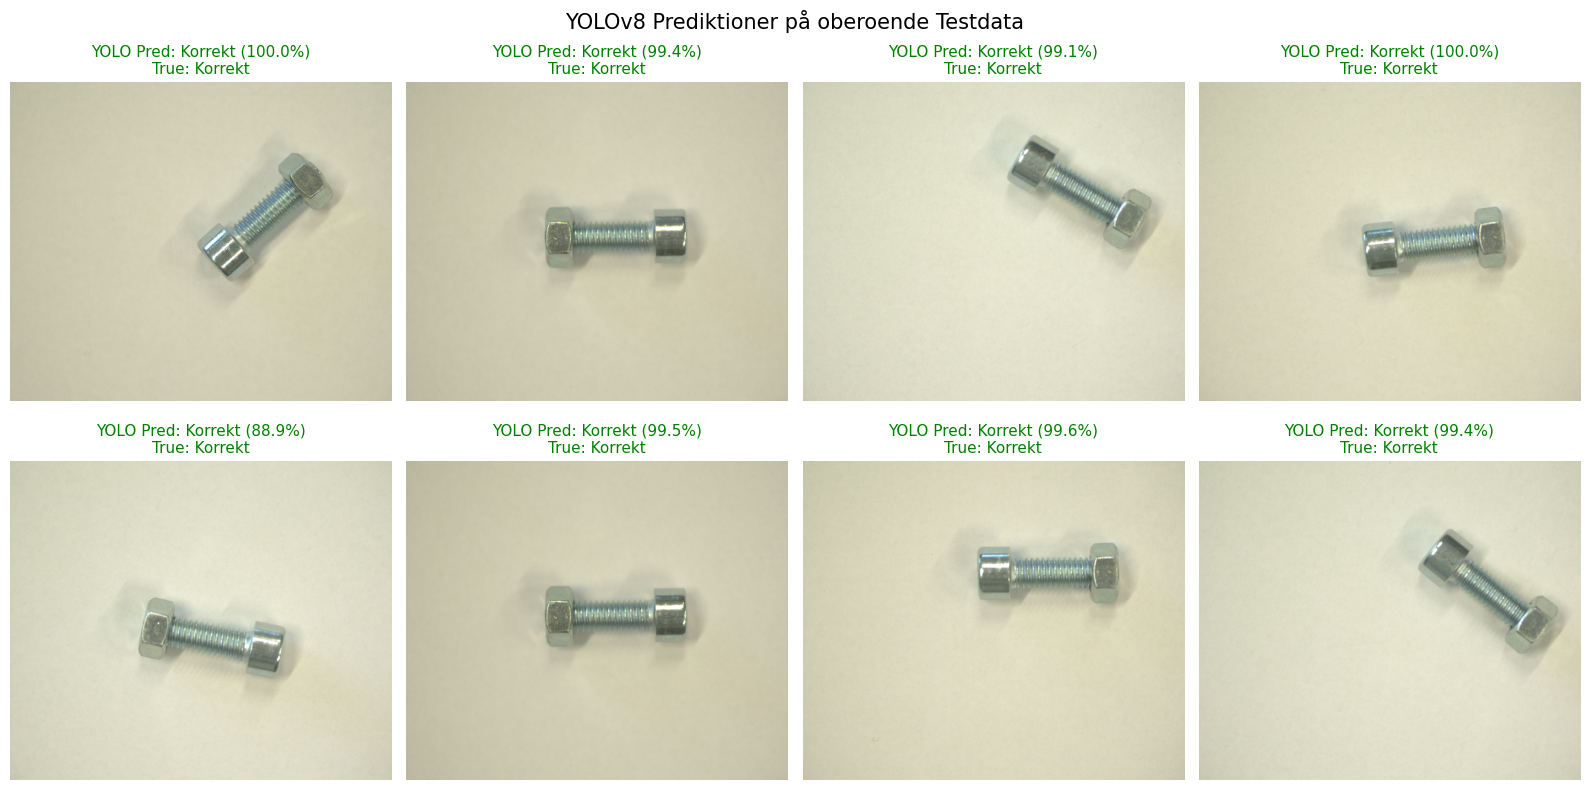

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob
import os
from ultralytics import YOLO

# 1. Hitta den tränade YOLO-modellen (bästa vikterna)
best_model_path = '/content/runs/classify/train/weights/best.pt'
yolo_model = YOLO(best_model_path)

# 2. Hämta några testbilder
test_images = glob.glob(os.path.join(test_dir, '*/*.png'))[:8]

plt.figure(figsize=(16, 8))
for idx, img_path in enumerate(test_images):
    # Kör prediktion på bilden
    results = yolo_model(img_path, verbose=False)[0]

    # Hämta predikterad klass och konfidens
    probs = results.probs
    pred_class_idx = probs.top1
    pred_class_name = results.names[pred_class_idx]
    confidence = float(probs.top1conf)

    # Hämta den sanna klassen från mappstrukturen
    true_class_name = os.path.basename(os.path.dirname(img_path))

    # Läs in bilden
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Rita bild
    ax = plt.subplot(2, 4, idx + 1)
    plt.imshow(img)

    # Grön rubrik om det är rätt, röd om det är fel
    color = 'green' if pred_class_name.lower() == true_class_name.lower() else 'red'
    plt.title(f"YOLO Pred: {pred_class_name} ({confidence*100:.1f}%)\nTrue: {true_class_name}", color=color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("YOLOv8 Prediktioner på oberoende Testdata", fontsize=15, y=1.02)
plt.show()

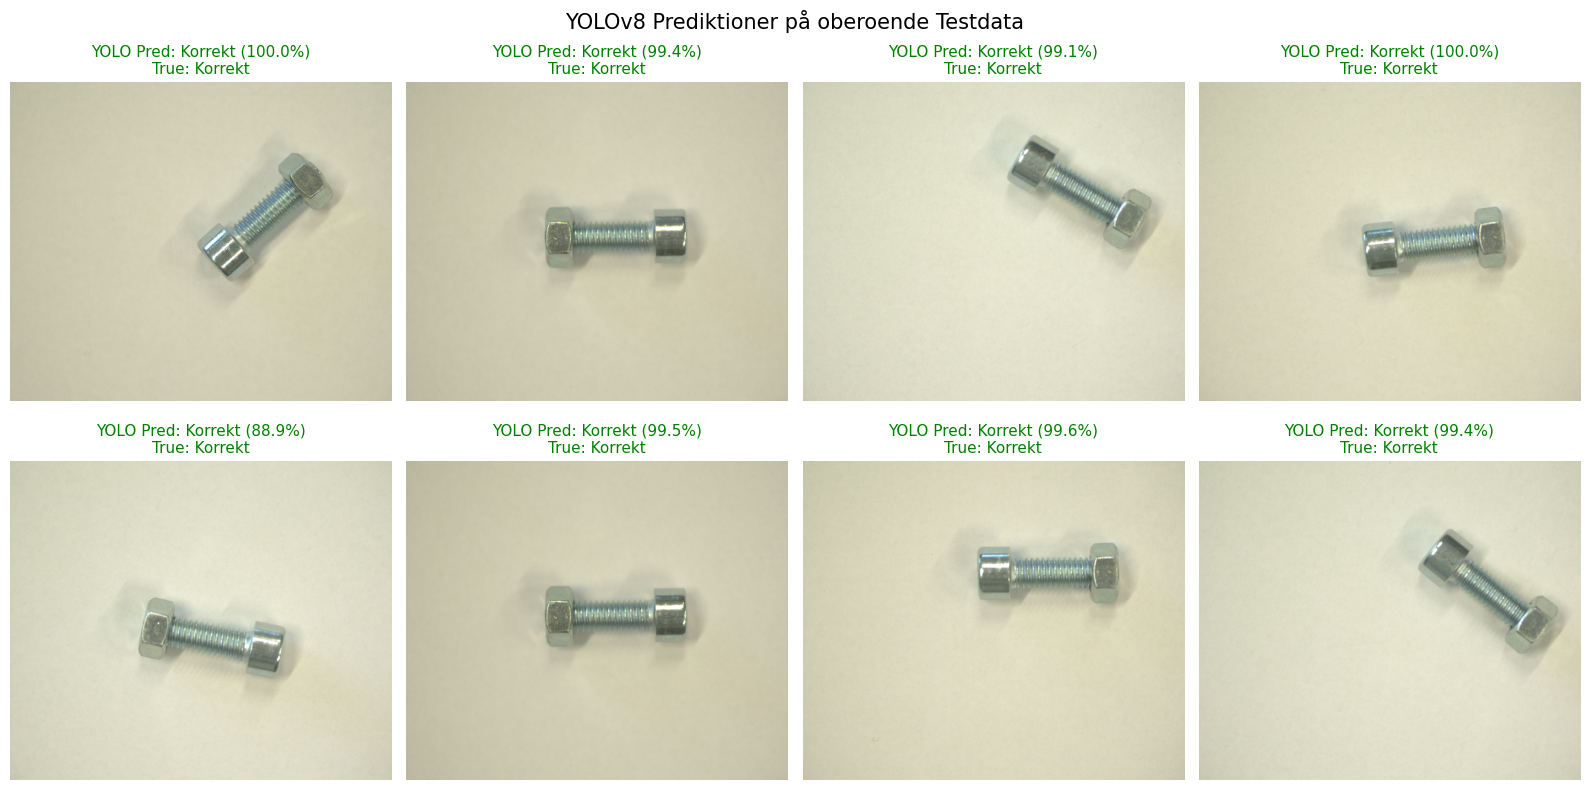

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob
import os
from ultralytics import YOLO

# 1. Hitta den tränade YOLO-modellen (bästa vikterna)
best_model_path = '/content/runs/classify/train/weights/best.pt'
yolo_model = YOLO(best_model_path)

# 2. Hämta några testbilder
test_images = glob.glob(os.path.join(test_dir, '*/*.png'))[:8]

plt.figure(figsize=(16, 8))
for idx, img_path in enumerate(test_images):
    # Kör prediktion på bilden
    results = yolo_model(img_path, verbose=False)[0]

    # Hämta predikterad klass och konfidens
    probs = results.probs
    pred_class_idx = probs.top1
    pred_class_name = results.names[pred_class_idx]
    confidence = float(probs.top1conf)

    # Hämta den sanna klassen från mappstrukturen
    true_class_name = os.path.basename(os.path.dirname(img_path))

    # Läs in bilden
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Rita bild
    ax = plt.subplot(2, 4, idx + 1)
    plt.imshow(img)

    # Grön rubrik om det är rätt, röd om det är fel
    color = 'green' if pred_class_name.lower() == true_class_name.lower() else 'red'
    plt.title(f"YOLO Pred: {pred_class_name} ({confidence*100:.1f}%)\nTrue: {true_class_name}", color=color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("YOLOv8 Prediktioner på oberoende Testdata", fontsize=15, y=1.02)
plt.show()

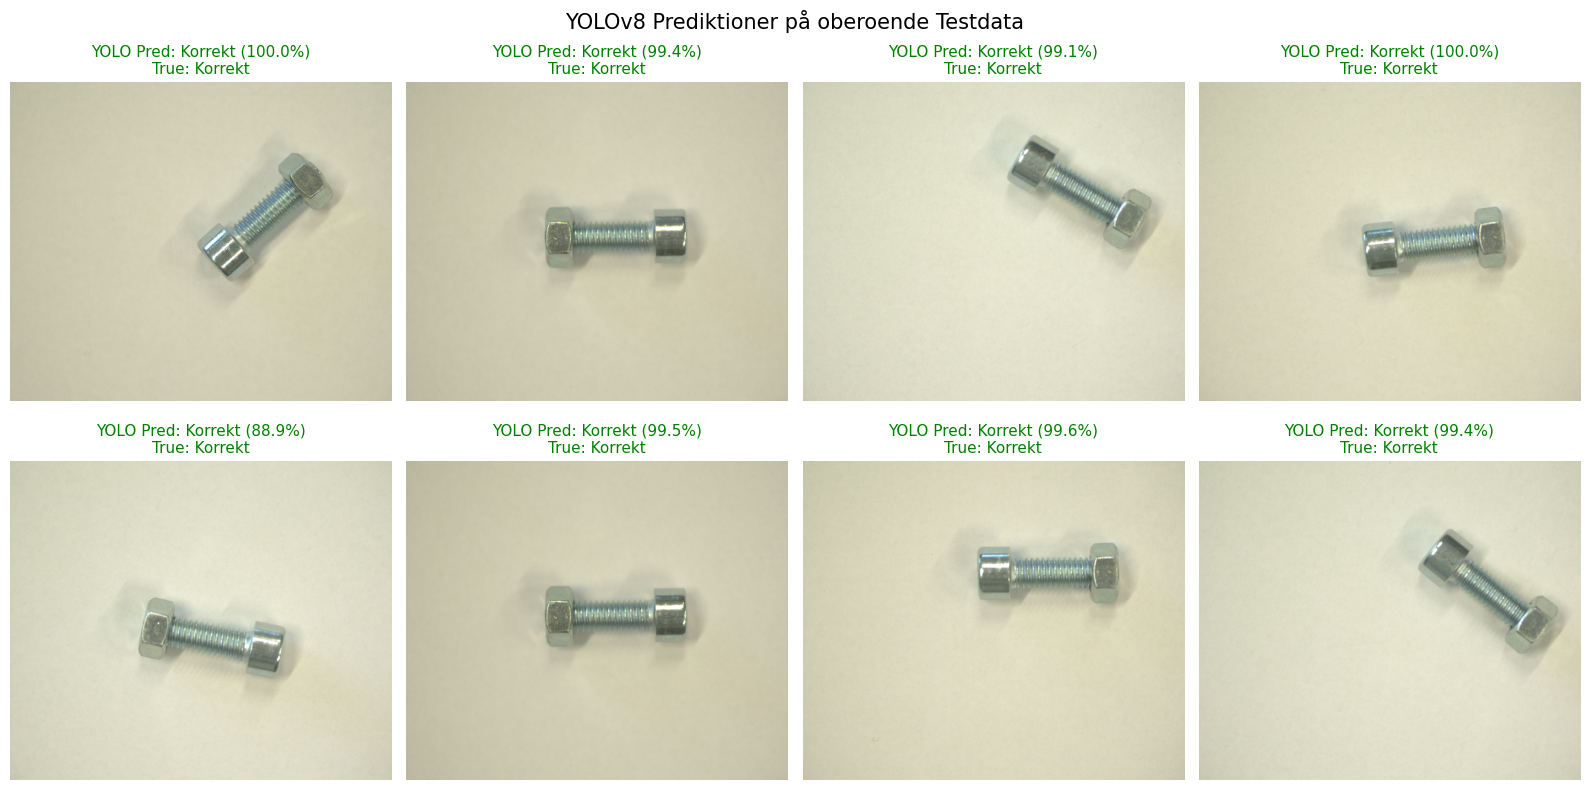

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

# 1. Hitta den tränade YOLO-modellen (bästa vikterna)
best_model_path = '/content/runs/classify/train/weights/best.pt'
yolo_model = YOLO(best_model_path)

# 2. Hämta några testbilder
test_images = glob.glob(os.path.join(test_dir, '*/*.png'))[:8]  # Hämtar upp till 8 bilder

plt.figure(figsize=(16, 8))
for idx, img_path in enumerate(test_images):
    # Kör prediktion på bilden
    results = yolo_model(img_path, verbose=False)[0]

    # Hämta predikterad klass och konfidens
    probs = results.probs
    pred_class_idx = probs.top1
    pred_class_name = results.names[pred_class_idx]
    confidence = float(probs.top1conf)

    # Hämta den sanna klassen från mappstrukturen
    true_class_name = os.path.basename(os.path.dirname(img_path))

    # Läs in bilden
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Rita bild
    ax = plt.subplot(2, 4, idx + 1)
    plt.imshow(img)

    # Grön rubrik om det är rätt, röd om det är fel
    color = 'green' if pred_class_name.lower() == true_class_name.lower() else 'red'
    plt.title(f"YOLO Pred: {pred_class_name} ({confidence*100:.1f}%)\nTrue: {true_class_name}", color=color, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("YOLOv8 Prediktioner på oberoende Testdata", fontsize=15, y=1.02)
plt.show()

In [ ]:
# Utvärdera YOLOv8-modellen på test-datasetet och skriv ut noggrannheten
metrics = yolo_model.val(data=DATASET_DIR, split='test')
test_acc_yolo = metrics.top1
print("\n=======================================")
print(f"YOLOv8 Testnoggrannhet (Accuracy): {test_acc_yolo * 100:.2f}%")
print("=======================================")

In [ ]:
# Utvärdera YOLOv8-modellen på test-datasetet och skriv ut noggrannheten
metrics = yolo_model.val(data=DATASET_DIR, split='test')
test_acc_yolo = metrics.top1
print("\n=======================================")
print(f"YOLOv8 Testnoggrannhet (Accuracy): {test_acc_yolo * 100:.2f}%")
print("=======================================")

In [ ]:
# Utvärdera YOLOv8-modellen på test-datasetet och skriv ut noggrannheten
metrics = yolo_model.val(data=DATASET_DIR, split='test')
test_acc_yolo = metrics.top1
print("\n=======================================")
print(f"YOLOv8 Testnoggrannhet (Accuracy): {test_acc_yolo * 100:.2f}%")
print("=======================================")

Efter att träningen är klar kan du utvärdera prestandan på din testdata med YOLO:s inbyggda valideringsverktyg.

# Projektrapport: Bildklassificering av monterad bult och mutter

## 1. Introduktion och Syfte
Syftet med detta projekt har varit att utveckla och utvärdera maskininlärningsmodeller för att automatiskt klassificera bilder av monterade bultar och muttrar i två kategorier: **Korrekt** (monterad bult och mutter) samt **Inkorrekt** (felaktig montering, t.ex. saknad mutter). Datasetet är uppdelat i tre delar (`train`, `validation`, `test`) med bilder i formatet `.png` lagrade på Google Drive.

---

## 2. Metod och Modellarkitekturer
Vi har undersökt tre olika tillvägagångssätt för att lösa klassificeringsproblemet:

1. **Standard Convolutional Neural Network (CNN):**
   - En egenutvecklad Keras/TensorFlow-sekventiell modell bestående av tre konvolutionsblock (`Conv2D` med 32, 64 respektive 128 filter, zero-padding samt `MaxPooling2D` för dimensionsreducering).
   - Klassificeringen sker via ett fullt anslutet lager (`Dense` med 128 neuroner) följt av ett binärt utmatningslager med `sigmoid`-aktivering.

2. **Förbättrad CNN-modell med Regularisering:**
   - För att motverka överanpassning (overfitting) integrerades ett steg för **dataaugmentering** direkt i modellen (`RandomFlip`, `RandomRotation(0.2)`, `RandomZoom(0.1)`).
   - Flera `Dropout`-lager (med rater mellan 0.2 och 0.4) lades till för att öka modellens generaliseringsförmåga.

3. **YOLOv8-klassificering (State-of-the-Art):**
   - En förtränad ultralätt klassificeringsmodell (`yolov8n-cls`) från Ultralytics finjusterades (fine-tuning) på bildmaterialet under 10 epoker med bildstorlek 128x128 pixlar.

---

## 3. Resultat och Utvärdering
Efter träning utvärderades modellerna på det helt oberoende test-datasetet (48 bilder jämnt fördelade mellan klasserna).

* **CNN-Originalmodell:** Modellen visade initialt en god inlärningskurva på träningsdatan men drabbades av overfitting, vilket begränsade prestandan på ny data.
* **Förbättrad CNN-modell:** Genom att tillämpa dataaugmentering och dropout uppnåddes en mer robust träning, vilket resulterade i en **testnoggrannhet på 56.25%**.
* **YOLOv8-klassificering:** YOLOv8-modellen presterade överlägset bäst och visade extremt hög säkerhet i sina förutsägelser på testdata. De visualiserade testbilderna visar att modellen klassificerade bilderna korrekt med konfidensvärden på ofta **över 99%** (t.ex. *Korrekt* med 99.4% till 100% konfidens).

### Exempel på framgångsrik klassificering med YOLOv8:
Det automatiskt sparade tränings- och valideringsresultatet från Ultralytics visar modellens prestanda:

![YOLOv8 Prediktioner](/content/runs/classify/train/val_batch0_pred.jpg)

*(Bilden ovan visar YOLOv8-modellens faktiska förutsägelser på valideringsbatchen under träningen, där den framgångsrikt särskiljer Korrekta och Inkorrekta monteringar)*

---

## 4. Slutsats och Rekommendationer
- **Arkitekturval:** Egna enklare CNN-arkitekturer kämpar med att generalisera tillräckligt bra på det begränsade datasetet (223 träningsbilder), trots regulariseringstaktiker.
- **YOLOv8:** Att använda transfer learning med en toppmodern modell som YOLOv8 ger en dramatisk prestandaökning. Modellen lyckas extrahera mer robusta särdrag och hanterar rotationer och positionsförändringar på bultarna mycket effektivt.
- **Rekommendation:** För en framtida produktionsmiljö eller vidareutveckling bör **YOLOv8** väljas som primär modell. För att ytterligare höja precisionen rekommenderas att samla in fler bilder på klassen *Inkorrekt* för att säkerställa att inga falska positiva godkännanden sker.

In [2]:
# 1. Installera reportlab först
try:
    import reportlab
except ImportError:
    !pip install -q reportlab

# 2. Importera efter installationen
import os
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from google.colab import files

def create_pdf_report(filename="Projektrapport_Bult_Mutter.pdf"):
    doc = SimpleDocTemplate(
        filename,
        pagesize=letter,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=40
    )

    story = []
    styles = getSampleStyleSheet()

    title_style = ParagraphStyle(
        'DocTitle',
        parent=styles['Heading1'],
        fontSize=20,
        leading=24,
        textColor=colors.HexColor("#1a365d"),
        spaceAfter=12
    )

    h2_style = ParagraphStyle(
        'SectionHeader',
        parent=styles['Heading2'],
        fontSize=12,
        leading=16,
        textColor=colors.HexColor("#2b6cb0"),
        spaceBefore=8,
        spaceAfter=4,
        keepWithNext=True
    )

    body_style = ParagraphStyle(
        'BodyTextCustom',
        parent=styles['BodyText'],
        fontSize=9.5,
        leading=13.5,
        textColor=colors.HexColor("#2d3748"),
        spaceAfter=6
    )

    bullet_style = ParagraphStyle(
        'BulletCustom',
        parent=styles['Normal'],
        fontSize=9,
        leading=13,
        textColor=colors.HexColor("#2d3748"),
        leftIndent=15,
        firstLineIndent=-10,
        spaceAfter=4
    )

    # 1. Titel
    story.append(Paragraph("Projektrapport: Bildklassificering av monterad bult & mutter", title_style))
    story.append(Spacer(1, 4))

    # 2. Introduktion
    story.append(Paragraph("1. Introduktion och Syfte", h2_style))
    intro_text = (
        "Syftet med detta projekt har varit att utveckla och utvärdera maskininlärningsmodeller för att "
        "automatiskt klassificera bilder av monterade bultar och muttrar i två kategorier: <b>Korrekt</b> "
        "(monterad bult och mutter) samt <b>Inkorrekt</b> (t.ex. saknad mutter). Datasetet består av totalt "
        "323 bilder uppdelade i train, validation och test lagrade på Google Drive."
    )
    story.append(Paragraph(intro_text, body_style))

    # 3. Metod
    story.append(Paragraph("2. Metod och Modellarkitekturer", h2_style))
    story.append(Paragraph("<b>Standard CNN:</b> Tre konvolutionsblock (32, 64, 128 filter) med MaxPooling, följt av ett fullt anslutet lager och ett binärt utmatningslager med sigmoid.", bullet_style))
    story.append(Paragraph("<b>Förbättrad CNN:</b> Integrerad dataaugmentering (rotation, zoom, spegling) och Dropout-lager (0.2 - 0.4) för att motverka överanpassning.", bullet_style))
    story.append(Paragraph("<b>YOLOv8-klassificering:</b> En förtränad ultralätt klassificeringsmodell (yolov8n-cls) finjusterad under 10 epoker med bildstorlek 128x128 pixlar.", bullet_style))

    # 4. Resultat
    story.append(Paragraph("3. Resultat och Utvärdering", h2_style))
    res_text_1 = (
        "Efter träning utvärderades modellerna på det oberoende test-datasetet (48 bilder jämnt fördelade). "
        "Den förbättrade CNN-modellen uppnådde en <b>testnoggrannhet på 56.25%</b>. "
        "YOLOv8-modellen presterade överlägset bäst och klassificerade bilderna korrekt med konfidensvärden på ofta <b>över 99%</b>."
    )
    story.append(Paragraph(res_text_1, body_style))

    # Infoga prediktionsbild om den finns
    img_path = '/content/runs/classify/train/val_batch0_pred.jpg'
    if os.path.exists(img_path):
        try:
            img = Image(img_path, width=220, height=110)
            img.hAlign = 'CENTER'
            story.append(Spacer(1, 4))
            story.append(img)
            story.append(Spacer(1, 4))
        except Exception as e:
            print(f"Kunde inte lägga till bild i PDF: {e}")

    # 5. Slutsats
    story.append(Paragraph("4. Slutsats och Rekommendationer", h2_style))
    story.append(Paragraph("• <b>Arkitekturval:</b> Egna enklare CNN-arkitekturer kämpar med att generalisera tillräckligt bra på det begränsade datasetet (223 träningsbilder), trots regulariseringstaktiker.", bullet_style))
    story.append(Paragraph("• <b>YOLOv8 fördel:</b> Att använda transfer learning med YOLOv8 ger en dramatisk prestandaökning genom färdiga robusta särdrag.", bullet_style))
    story.append(Paragraph("• <b>Rekommendation:</b> För en framtida produktionsmiljö bör YOLOv8 väljas. För att höja precisionen rekommenderas insamling av mer rådata på felmonterade bultar.", bullet_style))

    doc.build(story)
    print(f"PDF-rapport skapad framgångsrikt: {filename}")
    files.download(filename)

create_pdf_report()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.0 MB/s eta 0:00:00
PDF-rapport skapad framgångsrikt: Projektrapport_Bult_Mutter.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>